# SGTR-RL Training Analysis

In [1]:
import sys
sys.path.insert(0, '..')

from notebooks.utils import load_latest_run, load_run, list_runs
from notebooks.plotting import (
    plot_dashboard, plot_accuracy, plot_accuracy_over_time,
    plot_reward, plot_datums, plot_batch_time,
    plot_progress, plot_cumulative_time, plot_epoch_summary,
)
import matplotlib.pyplot as plt
%matplotlib inline

## Load Run

In [2]:
# List available runs
for p in list_runs():
    print(p.name)

03_RL_grpo_IND_ShareGPT_CoT__20260223_192913


In [3]:
run = load_latest_run()
print(run.summary())

Experiment: 03_RL_grpo_IND_ShareGPT_CoT
Model: meta-llama/Llama-3.1-8B-Instruct (LoRA rank=32)
Steps: 240 (3 epochs x 80 batches)
Wall time: 72 min (1.2 hr)
  Epoch 1: reward=0.501, acc=50.1%
  Epoch 2: reward=0.520, acc=51.1%
  Epoch 3: reward=0.514, acc=51.2%
Datums: avg=16.2, zero=8% of batches


## Dashboard

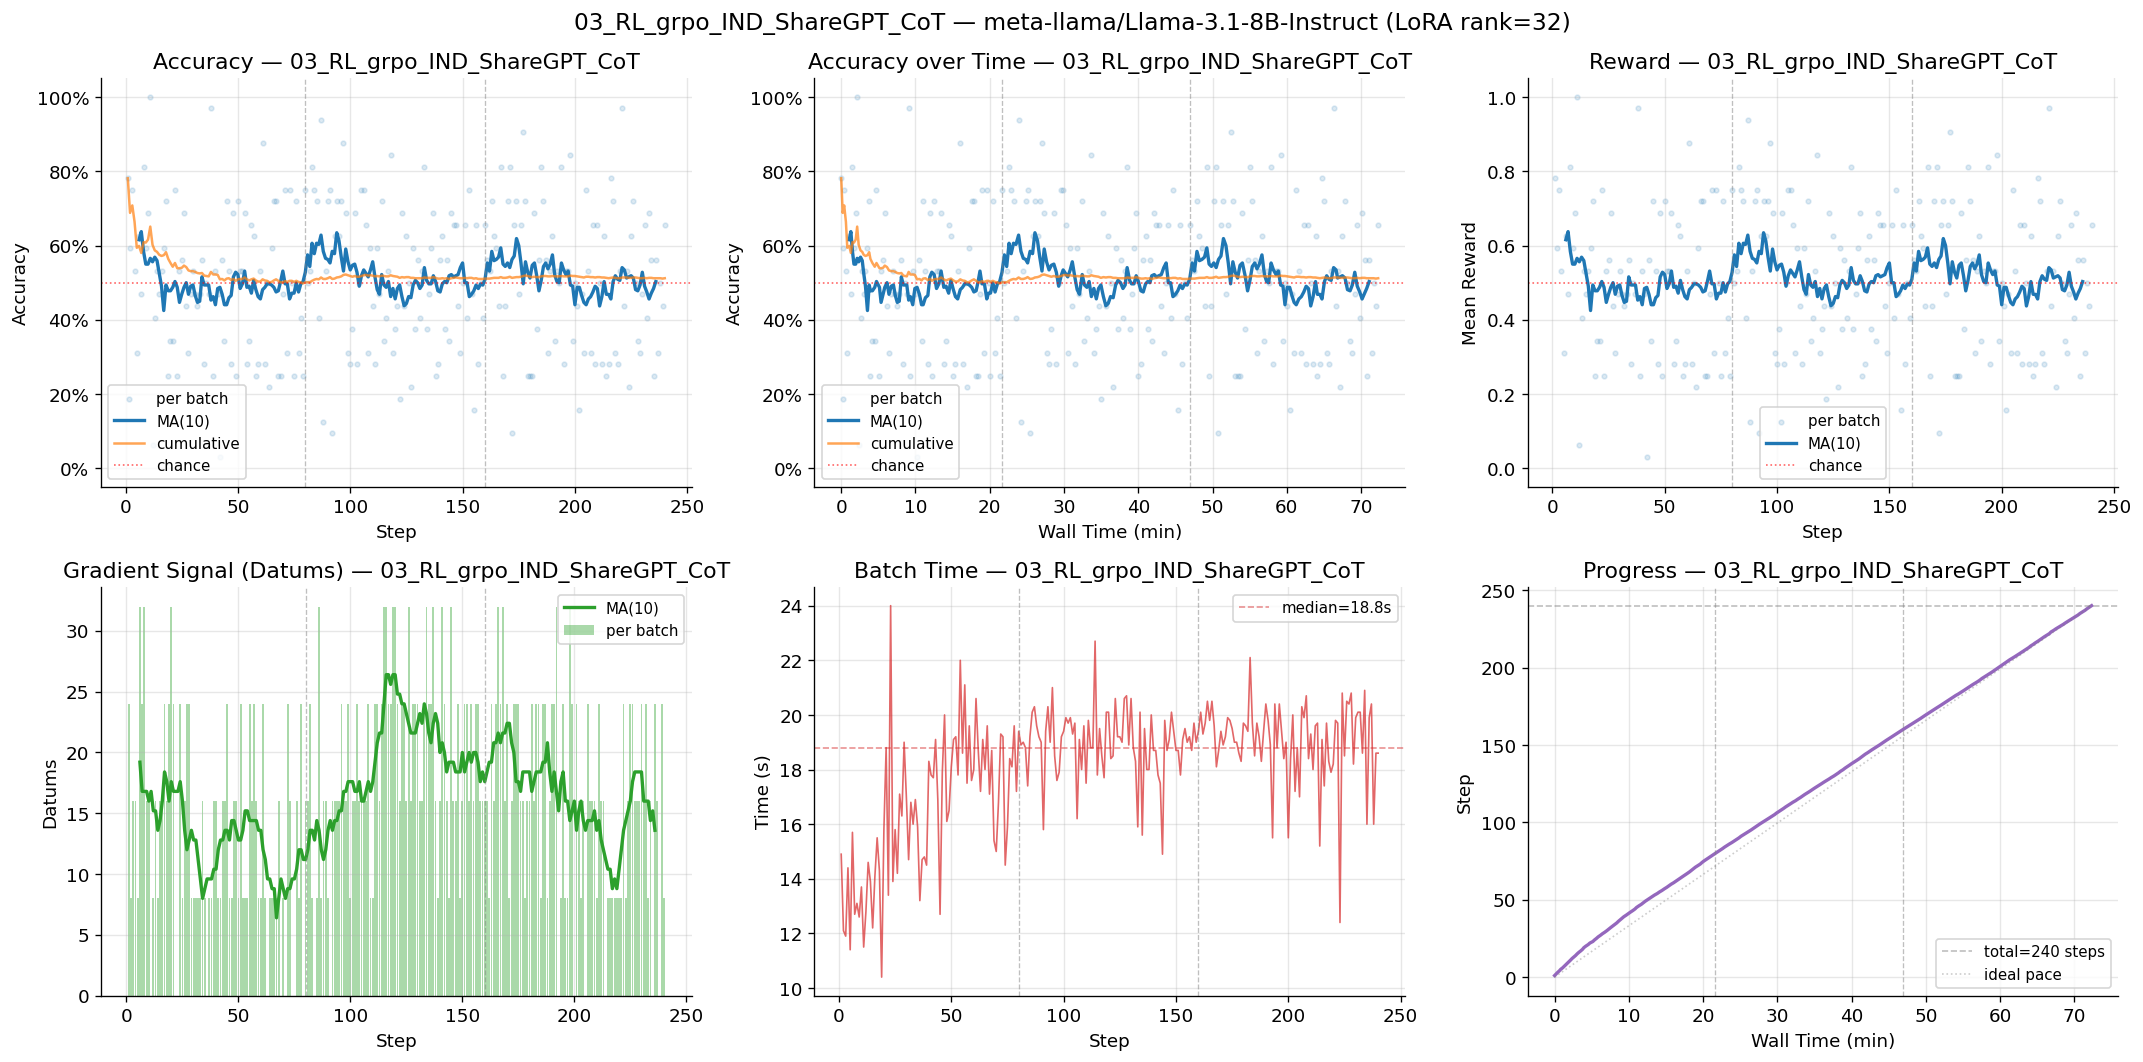

In [4]:
fig = plot_dashboard(run, window=10)
plt.show()

## Accuracy

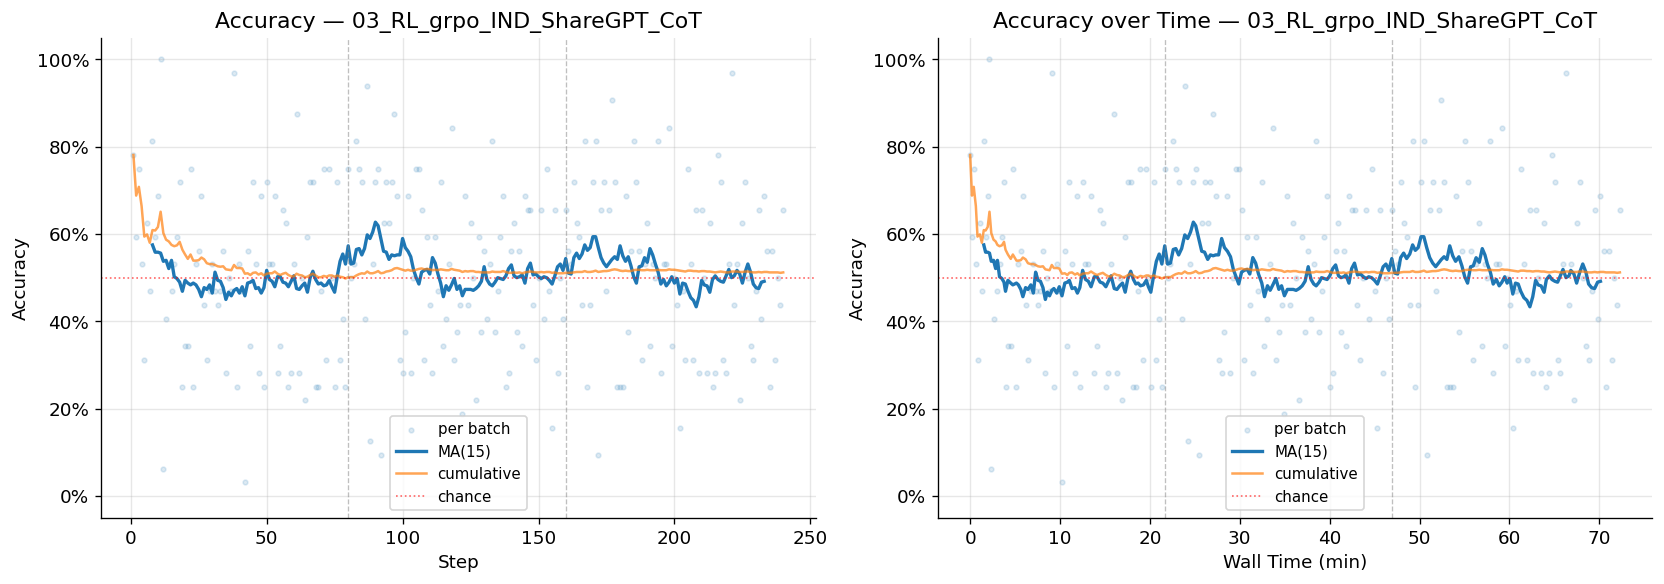

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_accuracy(run, window=15, ax=axes[0])
plot_accuracy_over_time(run, window=15, ax=axes[1])
plt.tight_layout()
plt.show()

## Reward

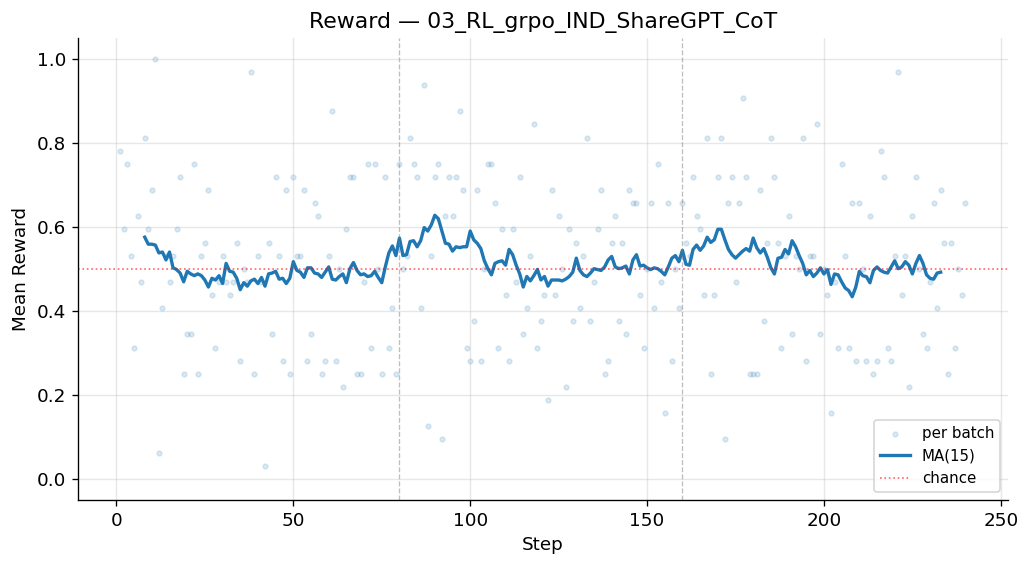

In [6]:
plot_reward(run, window=15)
plt.show()

## Gradient Signal (Datums)

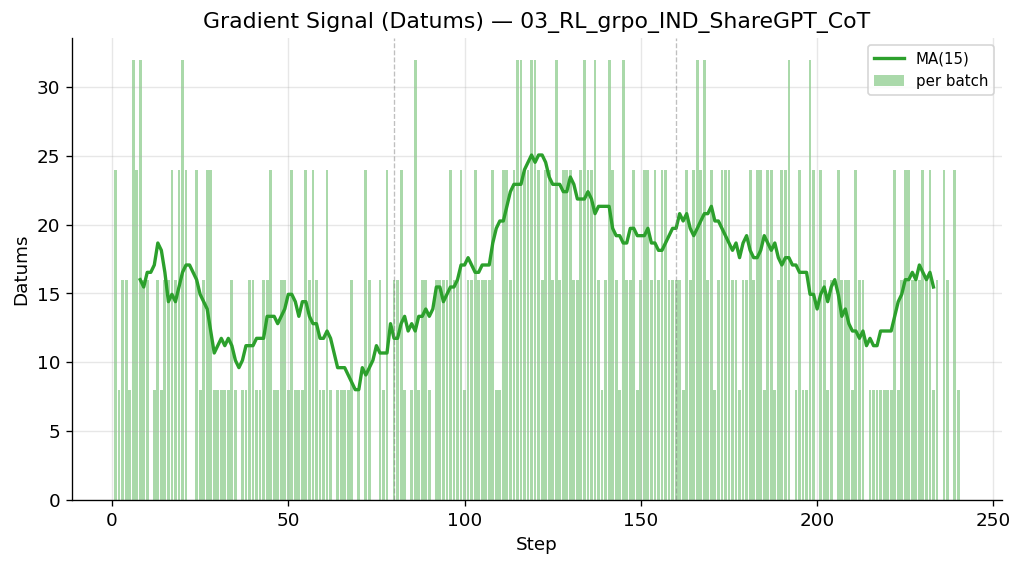

In [7]:
plot_datums(run, window=15)
plt.show()

## Timing

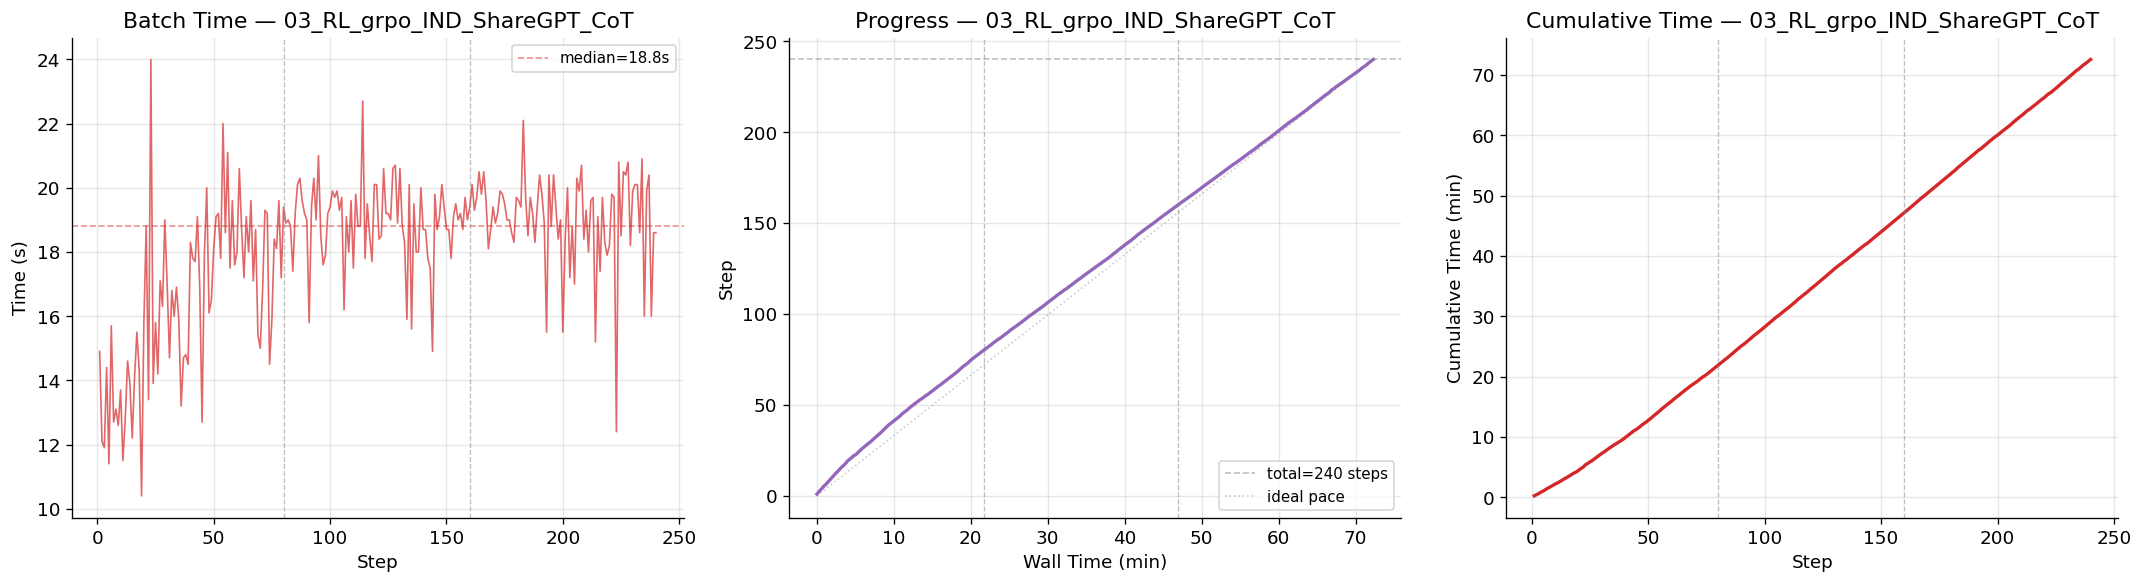

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_batch_time(run, ax=axes[0])
plot_progress(run, ax=axes[1])
plot_cumulative_time(run, ax=axes[2])
plt.tight_layout()
plt.show()

## Epoch Summary

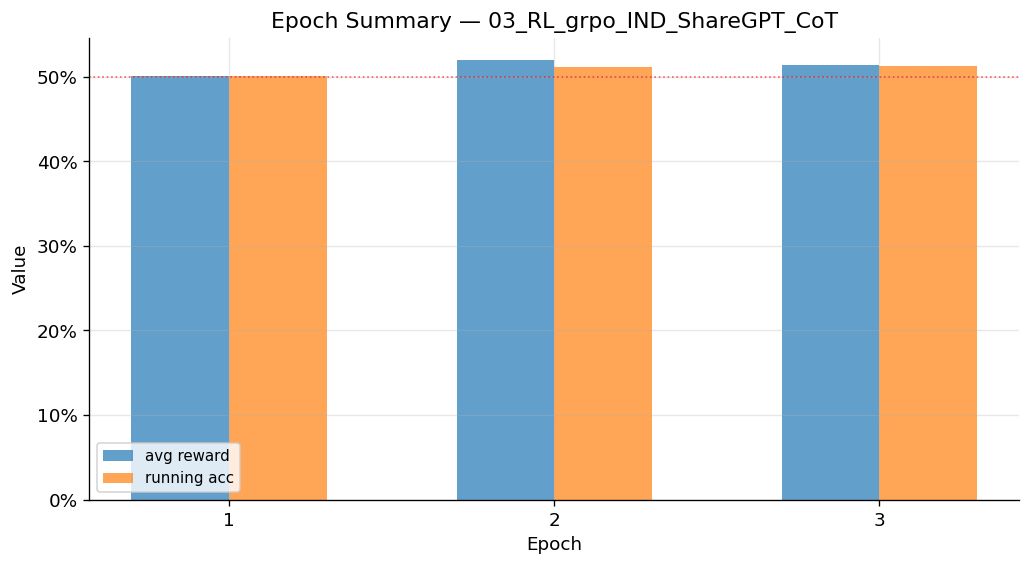

In [9]:
plot_epoch_summary(run)
plt.show()

## Per-Epoch Breakdown

In [10]:
import numpy as np

for epoch_num in range(1, run.n_epochs + 1):
    epoch_batches = [b for b in run.batches if b.epoch == epoch_num]
    accs = [b.acc for b in epoch_batches]
    datums = [b.datums for b in epoch_batches]
    times = [b.elapsed for b in epoch_batches]
    
    print(f"Epoch {epoch_num}:")
    print(f"  Accuracy: mean={np.mean(accs):.1%}, std={np.std(accs):.1%}")
    print(f"  Datums:   mean={np.mean(datums):.1f}, zero={sum(1 for d in datums if d==0)}/{len(datums)} batches")
    print(f"  Time:     mean={np.mean(times):.1f}s, total={sum(times)/60:.1f}min")
    print()

Epoch 1:
  Accuracy: mean=50.1%, std=20.0%
  Datums:   mean=13.1, zero=10/80 batches
  Time:     mean=16.4s, total=21.9min

Epoch 2:
  Accuracy: mean=52.0%, std=18.8%
  Datums:   mean=19.2, zero=2/80 batches
  Time:     mean=18.9s, total=25.3min

Epoch 3:
  Accuracy: mean=51.4%, std=19.3%
  Datums:   mean=16.2, zero=6/80 batches
  Time:     mean=19.0s, total=25.4min

